# Banco de dados MNIST

![Exemplo MNIST](imgs/mnist-3.0.1.png)

O **banco de dados MNIST** (Modified National Institute of Standards and Technology database) é um conjunto de dados clássico em aprendizado de máquina e visão computacional.

Ele consiste em:

- **70.000 imagens em tons de cinza** de dígitos manuscritos (0–9)
  - **60.000 imagens para treinamento**
  - **10.000 imagens para teste**
- Cada imagem possui **28x28 pixels** (achatada para 784 características em muitos modelos)
- Cada imagem é rotulada com o dígito correto (0–9)

**Propósito:**

O MNIST é amplamente utilizado para treinar e testar algoritmos de classificação de imagens, especialmente para avaliação de redes neurais e modelos de deep learning.

**Uso típico:**

- **Entrada:** Imagem de 28x28 pixels (geralmente achatada para um vetor de tamanho 784)
- **Saída:** Rótulo do dígito (0–9)

**Por que é popular?**

- Simples e bem compreendido
- Pequeno o suficiente para experimentos rápidos
- Bom para aprender e prototipar modelos de classificação de imagens

### 1. Download

In [1]:
from utils import mnist

In [2]:
# mnist.download_mnist()

### 2. Carrega dados memoria

In [3]:
X_train, y_train, X_test, y_test = mnist.load()

#### 2.1 Estrutura features

In [4]:
X_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(60000, 784), dtype=uint8)

#### 2.2 Exemplo de 1 elemento

In [5]:
import numpy as np

np.set_printoptions(linewidth=32*4)  

print(X_train[2].reshape(28, 28))  

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  67 232  39   0   0   0   0   0]
 [  0   0   0   0  62  81   0   0   0   0   0   0   0   0   0   0   0   0   0   0 120 180  39   0   0   0   0   0]
 [  0   0   0   0 126 163   0   0   0   0   0   0   0   0   0   0   0   0   0   2 153 210  40   0   0   0   0   0]
 [  0   0   0   0 220 163   0   0   0   0   0   0   0   0   0   0   0   0   0  2

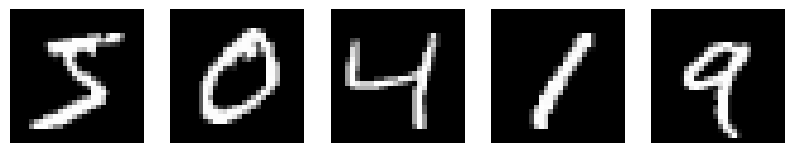

In [6]:
import matplotlib.pyplot as plt

# Number of samples to display
num_samples = 5

# Plot the first few samples
fig, axes = plt.subplots(1, num_samples, figsize=(10, 2))
for i in range(num_samples):
    axes[i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    axes[i].axis('off')
plt.show()

#### 2.3 Estrutura target

In [7]:
y_train[0:5]

array([5, 0, 4, 1, 9])

In [8]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,))

#### 2.4 Transformacao do target

In [9]:
# one-hot encode
num_labels = len(y_train)
train_labels = np.zeros((num_labels, 10))
for i in range(num_labels):
    train_labels[i][y_train[i]] = 1

num_labels = len(y_test)
test_labels = np.zeros((num_labels, 10))
for i in range(num_labels):
    test_labels[i][y_test[i]] = 1

In [10]:
train_labels[0:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

#### 2.5 Transformacao das features

In [11]:
X_train, X_test = X_train - np.mean(X_train), X_test - np.mean(X_train)
X_train, X_test = X_train / np.std(X_train), X_test / np.std(X_train)

In [12]:
# X_train, X_test = X_train / 255, X_test /255

In [13]:
np.set_printoptions(linewidth=60*4) 
np.round(X_train[2].reshape(28, 28), 3)

array([[-0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424],
       [-0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424],
       [-0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424],
       [-0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424],
       [-0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.4

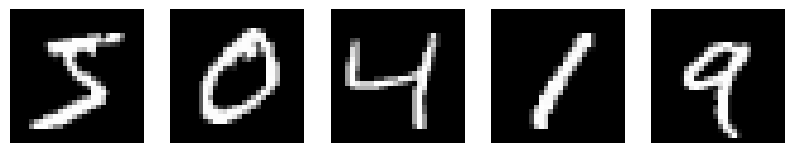

In [14]:
import matplotlib.pyplot as plt

# Number of samples to display
num_samples = 5

# Plot the first few samples
fig, axes = plt.subplots(1, num_samples, figsize=(10, 2))
for i in range(num_samples):
    axes[i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    axes[i].axis('off')
plt.show()

### 2. Arquitetura modelo e acuracia

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.int64)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.int64)

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 24)
        self.sigmoid = nn.Sigmoid()
        self.fc2 = nn.Linear(24, 10)
        self.softmax = nn.Softmax(dim=1)

        # nn.init.zeros_(self.fc1.weight)
        # nn.init.zeros_(self.fc1.bias)
        # nn.init.zeros_(self.fc2.weight)
        # nn.init.zeros_(self.fc2.bias)

    def forward(self, x):
        x = self.fc1(x)
        x = self.sigmoid(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x

model = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

epochs = 50
batch_size = 60

loss_history = []
for epoch in range(epochs):
    for i in range(0, X_train_tensor.size(0), batch_size):
        batch_x = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()
    if (epoch+1) % 2 == 0:
        loss_history.append(loss.item())
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

with torch.no_grad():
    outputs = model(X_test_tensor)
    predicted = torch.argmax(outputs, 1)
    accuracy = (predicted == y_test_tensor).float().mean().item()
    print(f"Test accuracy: {accuracy*100:.2f}%")


Epoch 2/50, Loss: 1.7753
Epoch 4/50, Loss: 1.6761
Epoch 6/50, Loss: 1.6326
Epoch 8/50, Loss: 1.6170
Epoch 10/50, Loss: 1.6076
Epoch 12/50, Loss: 1.5469
Epoch 14/50, Loss: 1.5157
Epoch 16/50, Loss: 1.5055
Epoch 18/50, Loss: 1.5009
Epoch 20/50, Loss: 1.4977
Epoch 22/50, Loss: 1.4949
Epoch 24/50, Loss: 1.4927
Epoch 26/50, Loss: 1.4911
Epoch 28/50, Loss: 1.4899
Epoch 30/50, Loss: 1.4890
Epoch 32/50, Loss: 1.4882
Epoch 34/50, Loss: 1.4874
Epoch 36/50, Loss: 1.4867
Epoch 38/50, Loss: 1.4860
Epoch 40/50, Loss: 1.4854
Epoch 42/50, Loss: 1.4848
Epoch 44/50, Loss: 1.4840
Epoch 46/50, Loss: 1.4832
Epoch 48/50, Loss: 1.4823
Epoch 50/50, Loss: 1.4813
Test accuracy: 94.79%


This model is a simple feedforward neural network (also called a multilayer perceptron) implemented with PyTorch for classifying handwritten digits from the MNIST dataset. Here’s a summary:

- **Input Layer:** Takes a 784-dimensional vector (flattened 28x28 image).
- **Hidden Layer:** One fully connected layer with 24 neurons and a sigmoid activation function.
- **Output Layer:** Another fully connected layer with 10 neurons (one for each digit 0–9), followed by a softmax activation to output probabilities for each class.
- **Training:** Uses cross-entropy loss and stochastic gradient descent (SGD) optimizer.
- **Purpose:** Learns to map input images to the correct digit label by adjusting weights during training.

This architecture is simple but effective for basic image classification tasks like MNIST.

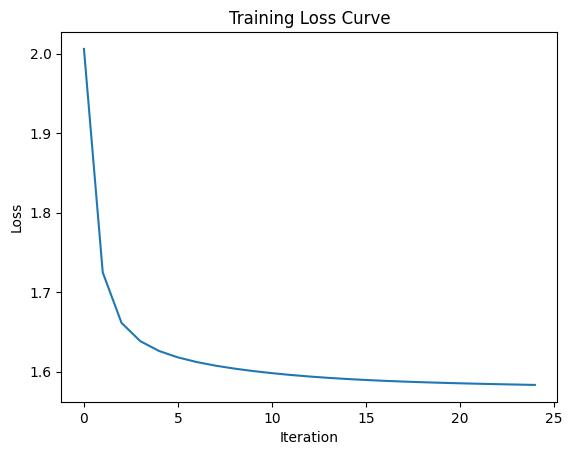

In [ ]:
plt.plot(loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()

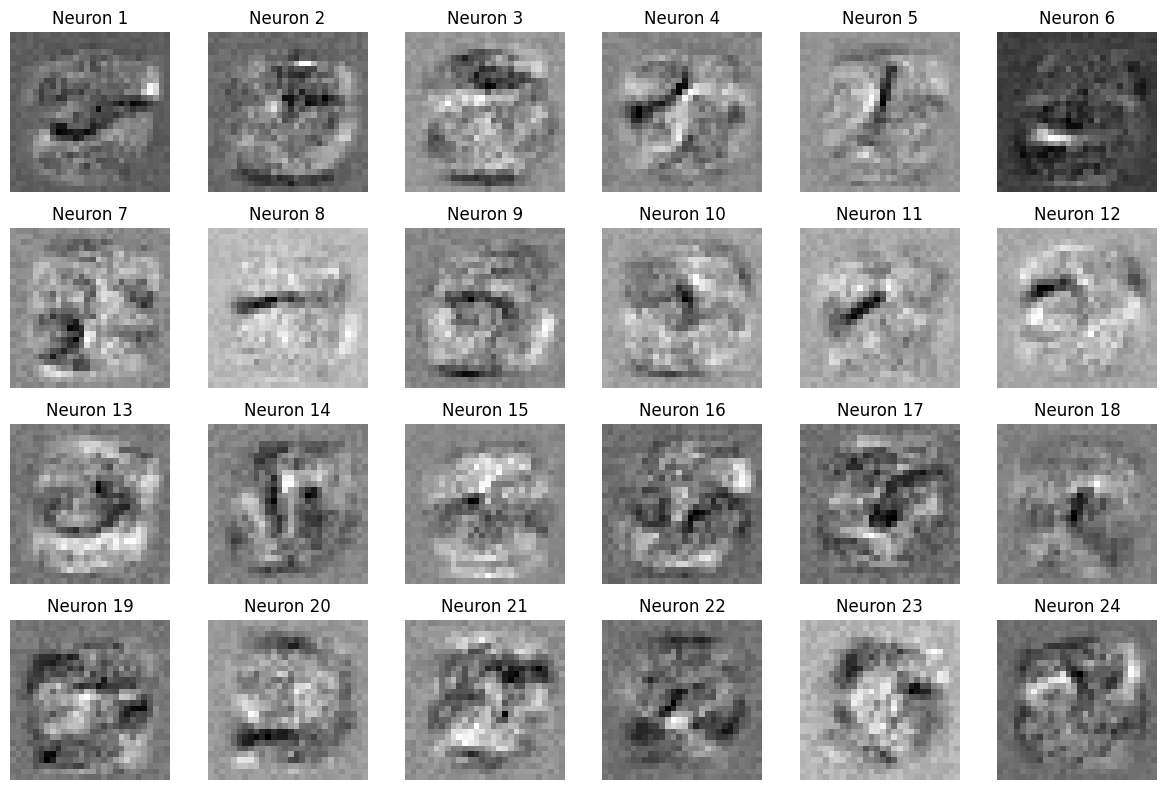

In [19]:
# Visualizacao dos pesos da primeira camada
weights = model.fc1.weight.data.numpy()
fig, axes = plt.subplots(4, 6, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    if i < 24:
        ax.imshow(weights[i].reshape(28, 28), cmap='gray')
        ax.set_title(f'Neuron {i+1}')
    ax.axis('off')
plt.tight_layout()
plt.show()